# Importing all required libraries

In [ ]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [ ]:
# 1. Uninstall the conflicting versions
!pip uninstall -y protobuf google-cloud-aiplatform

# 2. Install the specific compatible versions
!pip install "protobuf==4.25.3"
!pip install -U flwr["simulation"]

# 3. Force-restart the backend (you'll see a 'Crash' message, ignore it, it's just the restart)
import os
os.kill(os.getpid(), 9)

In [ ]:
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate,
    GlobalAveragePooling2D, Conv2D, MaxPooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryFocalCrossentropy

import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.27.0
TensorFlow version: 2.19.0


# Kaggle setup

In [ ]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

# Model B

### Extracting dataset from kaggle

In [ ]:
!kaggle datasets download -d andrewmvd/leukemia-classification -p /content/

with zipfile.ZipFile('/content/leukemia-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/B_Raw/')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
100% 867M/867M [00:11<00:00, 79.4MB/s]



### Structuring folder

In [ ]:
base_path = '/content/Institution_Beta'
shutil.rmtree(base_path, ignore_errors=True)
os.makedirs(f'{base_path}/Healthy', exist_ok=True)
os.makedirs(f'{base_path}/Leukemia', exist_ok=True)

In [ ]:
physical_map = {}

for i, p in enumerate(glob.glob('/content/B_Raw/**/hem/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Healthy/B_H_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

for i, p in enumerate(glob.glob('/content/B_Raw/**/all/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Leukemia/B_L_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

print(f"Images Moved. Healthy: {len(os.listdir(base_path+'/Healthy'))}, Leukemia: {len(os.listdir(base_path+'/Leukemia'))}")

Images Moved. Healthy: 3389, Leukemia: 7272


### Importing Clinical Data

In [ ]:
df_beta = pd.read_csv('/content/hospital_B_clinical.csv')

In [ ]:
healthy_imgs_beta = sorted(glob.glob('/content/Institution_Beta/Healthy/*.bmp'))
leukemia_imgs_beta = sorted(glob.glob('/content/Institution_Beta/Leukemia/*.bmp'))

df_beta['image_path'] = None

for label, image_pool in [(0, healthy_imgs_beta), (1, leukemia_imgs_beta)]:
    patients_beta = sorted(df_beta[df_beta['Diagnosis'] == label]['Patient_ID'].unique())
    idx = 0

    for p in patients_beta:
        patient_idx = df_beta[(df_beta['Patient_ID'] == p) & (df_beta['Diagnosis'] == label)].index

        for i in range(len(patient_idx)):
            if idx >= len(image_pool):
                break

            df_beta.loc[patient_idx[i], 'image_path'] = image_pool[idx]
            idx += 1

df_beta = df_beta.dropna(subset=['image_path']).reset_index(drop=True)

In [ ]:
features_beta = [
    'WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
    'RBC_count', 'Hematocrit', 'Lymphocyte_percentage',
    'Neutrophil_percentage', 'Uric_acid'
]

print(f"Total valid images locked in for Beta: {len(df_beta)}")

Total valid images locked in for Beta: 10620


### Spliting data into train and test

In [ ]:
unique_patients_beta = df_beta['Patient_ID'].unique()

train_ids_beta, temp_ids_beta = train_test_split(
    unique_patients_beta, test_size=0.3, random_state=42
)

val_ids_beta, test_ids_beta = train_test_split(
    temp_ids_beta, test_size=0.5, random_state=42
)

train_df_beta = df_beta[df_beta['Patient_ID'].isin(train_ids_beta)].reset_index(drop=True)
val_df_beta   = df_beta[df_beta['Patient_ID'].isin(val_ids_beta)].reset_index(drop=True)
test_df_beta  = df_beta[df_beta['Patient_ID'].isin(test_ids_beta)].reset_index(drop=True)

print("Beta Train-Test overlap:", len(set(train_df_beta['Patient_ID']) & set(test_df_beta['Patient_ID'])))
print(f"Beta Split done: {len(train_df_beta)} Train, {len(val_df_beta)} Val, {len(test_df_beta)} Test rows.")

Beta Train-Test overlap: 0
Beta Split done: 7563 Train, 1663 Val, 1394 Test rows.


### Scaling tabular data

In [ ]:
scaler_beta = StandardScaler()

train_df_beta[features_beta] = scaler_beta.fit_transform(train_df_beta[features_beta])

val_df_beta[features_beta]   = scaler_beta.transform(val_df_beta[features_beta])
test_df_beta[features_beta]  = scaler_beta.transform(test_df_beta[features_beta])

print(f"Beta Scaling done: {len(train_df_beta)} Train rows scaled.")

Beta Scaling done: 7563 Train rows scaled.


### Class Weight

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_beta = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df_beta['Diagnosis'].values
)

class_weight_dict_beta = {0: class_weights_beta[0], 1: class_weights_beta[1]}

print(f"Beta Class Weights → Healthy: {class_weights_beta[0]:.2f}, Leukemia: {class_weights_beta[1]:.2f}")

Beta Class Weights → Healthy: 1.68, Leukemia: 0.71


### Data Agumentation

In [ ]:
aug_beta = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [ ]:
class LeukemiaDataGeneratorBeta(tf.keras.utils.Sequence):

    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True, is_training=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.is_training = is_training
        self.features = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

        self.on_epoch_end()

    def __len__(self):
      if self.is_training:
          return int(np.floor(len(self.df) / self.batch_size))
      else:
          return math.ceil(len(self.df) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle: self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        images = []

        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training: img = aug_beta.random_transform(img)
            images.append(img)

        X_img = np.array(images)
        X_tab = batch[self.features].values.astype(np.float32)

        y = batch['Diagnosis'].values.astype(np.float32)

        return (X_img, X_tab), y

In [ ]:
beta_train_gen = LeukemiaDataGeneratorBeta(train_df_beta, is_training=True)
beta_val_gen   = LeukemiaDataGeneratorBeta(val_df_beta,   shuffle=False, is_training=False)
beta_test_gen  = LeukemiaDataGeneratorBeta(test_df_beta,  shuffle=False, is_training=False)

### THE DUAL-INPUT ARCHITECTURE

In [ ]:
def build_model_beta():

    # --- IMAGE BRANCH ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(8, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH ---
    tab_input = Input(shape=(9,), name="clinical_input")
    t = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(tab_input)
    t = Dropout(0.4)(t)
    tab_features = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(t)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.4)(z)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss=BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )

    return model

In [ ]:
local_model_beta = build_model_beta()
local_model_beta.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 224, 224,  │        224 │ image_input[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 112, 112,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 112, 112,  │          0 │ max_pooling2d_4[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │      1,168 │ dropout_8[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 56, 56,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_5[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        160 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dropout_9[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16)        │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8)         │        136 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 40)        │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        656 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 16)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905 (11.35 KB)

 Trainable params: 2,905 (11.35 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [ ]:
class LeukemiaClientBeta(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator, class_weights):
        self.model = model
        self.train_gen = train_generator
        self.val_gen = val_generator
        self.class_weights = class_weights

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]

        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)
        print("\nTraining on local patient silo...")

        local_epochs = config.get("local_epochs", 2)
        self.model.fit(
            self.train_gen,
            epochs=local_epochs,
            class_weight=self.class_weights,
            verbose=1
        )

        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
callbacks_beta = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_beta.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history_beta = local_model_beta.fit(
    beta_train_gen,
    validation_data=beta_val_gen,
    epochs=15,
    callbacks=callbacks_beta,
    class_weight=class_weight_dict_beta,
    verbose=1
)

Epoch 1/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.6895 - auc: 0.7512 - loss: 0.1589 - precision: 0.8289 - recall: 0.7021
Epoch 1: val_loss improved from None to 0.12971, saving model to best_model_beta.keras

Epoch 1: finished saving model to best_model_beta.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 128s 512ms/step - accuracy: 0.6974 - auc: 0.7798 - loss: 0.1521 - precision: 0.8451 - recall: 0.6971 - val_accuracy: 0.8425 - val_auc: 0.9720 - val_loss: 0.1297 - val_precision: 1.0000 - val_recall: 0.7966
Epoch 2/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7339 - auc: 0.8451 - loss: 0.1335 - precision: 0.8881 - recall: 0.7115
Epoch 2: val_loss improved from 0.12971 to 0.10586, saving model to best_model_beta.keras

Epoch 2: finished saving model to best_model_beta.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 113s 480ms/step - accuracy: 0.7560 - auc: 0.8653 - loss: 0.1278 - precision: 0.9039 - recall: 0.7302 - val_accuracy: 0.8569 - val_auc: 0.9848 - val_loss: 0.1059 - val_

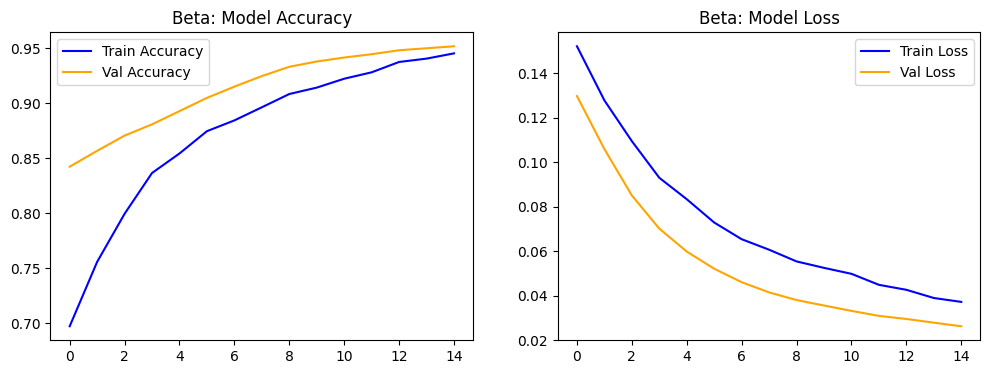

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_beta.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_beta.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Beta: Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_beta.history['loss'], label='Train Loss', color='blue')
plt.plot(history_beta.history['val_loss'], label='Val Loss', color='orange')
plt.title('Beta: Model Loss')
plt.legend()
plt.show()

In [ ]:
def evaluate_on_test(model, test_gen, test_df, title="Model"):
    all_probs = model.predict(test_gen, verbose=1).flatten()
    threshold = 0.3
    all_preds = (all_probs > threshold).astype(int)

    n = len(all_probs)
    all_true = test_df['Diagnosis'].values[:n].astype(int)

    # Core metrics
    acc  = accuracy_score(all_true, all_preds)
    auc  = roc_auc_score(all_true, all_probs)
    prec = precision_score(all_true, all_preds)
    rec  = recall_score(all_true, all_preds)
    f1   = f1_score(all_true, all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_true, all_preds)

    print(f"\n{'='*50}")
    print(f"  TEST SET RESULTS — {title}")
    print(f"{'='*50}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  Precision    : {prec:.4f}")
    print(f"  Recall       : {rec:.4f}")
    print(f"  F1 Score     : {f1:.4f}")
    print(f"{'='*50}\n")

    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds))

In [ ]:
evaluate_on_test(local_model_beta, beta_test_gen, test_df_beta, title="Institution Beta")

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step

  TEST SET RESULTS — Institution Beta
  Accuracy     : 0.9878
  AUC-ROC      : 0.9999
  Precision    : 0.9743
  Recall       : 1.0000
  F1 Score     : 0.9870

Confusion Matrix:
[[733  17]
 [  0 644]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       750
           1       0.97      1.00      0.99       644

    accuracy                           0.99      1394
   macro avg       0.99      0.99      0.99      1394
weighted avg       0.99      0.99      0.99      1394

